# Bayesian Deep Learning

Bayesian Deep Learning is a field that tries to quantify uncertainty in artificial neural networks. In this approach, the weights of a model are treated as distributions instead of fixed values.

In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

import torch
from torch.optim import Adam

from pai import BNNLA, BNNVI
from scoring import bnn_loss, negative_elbo

mpl.rc_file_defaults()

## Toy Data

In [2]:
rng = np.random.default_rng(42)

x_numpy = np.linspace(-6 * np.pi, 6 * np.pi, 1000).reshape((1000, 1))
x_short = np.concatenate([x_numpy[:20], x_numpy[40:80], x_numpy[100:120], x_numpy[150:]])
y_numpy = np.sin(0.2 * x_short) + rng.normal(0, 0.2, size=x_short.shape)

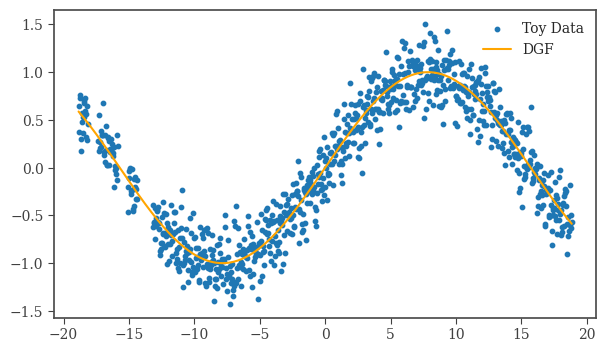

In [3]:
fig, ax = plt.subplots(figsize=(7, 4))

ax.scatter(x_short, y_numpy, label="Toy Data", s=10)
ax.plot(x_numpy, np.sin(0.2 * x_numpy), label="DGF", color="orange")
ax.legend()

plt.show()

## BNN with Laplace Approximation

A common problem with such Bayesian methods are intractable computations due to high computation costs. As such, it is common to use approximations. One possible approach are neural networks with Laplace Approximations, where the true posterior is approximated using a Gaussian distribution.

In [4]:
x = torch.from_numpy(x_short).to(torch.float32)
y = torch.from_numpy(y_numpy).to(torch.float32)

In [5]:
inv_prior = 0.009

bnn = BNNLA(x.shape[1], inv_prior)
optimizer = Adam(bnn.parameters(), lr=0.01, weight_decay=inv_prior)

for epoch in range(2_000):
    optimizer.zero_grad()

    y_mean, y_log_var = bnn(x)
    loss = bnn_loss(y_mean, y_log_var, y)
    loss.backward()

    optimizer.step()
    if epoch % 100 == 0:
        print(f"E{epoch}: Loss {loss.item():.4f}")

E0: Loss 0.3941
E100: Loss -0.9676
E200: Loss -1.1058
E300: Loss -1.1095
E400: Loss -1.1077
E500: Loss -0.9642
E600: Loss -1.1167
E700: Loss -1.1305
E800: Loss -1.1298
E900: Loss -1.1305
E1000: Loss -1.1224
E1100: Loss -1.1250
E1200: Loss -1.1273
E1300: Loss -1.1189
E1400: Loss -1.1319
E1500: Loss -1.0878
E1600: Loss -1.0824
E1700: Loss -1.0851
E1800: Loss -1.1042
E1900: Loss -1.1163


In [6]:
x_long = torch.from_numpy(x_numpy).to(torch.float32)

bnn.covariance(x_long)
y_pred, var_pred, total_var_pred = bnn.predict(x_long)

y_pred = y_pred.detach().numpy().ravel()
var_pred = var_pred.detach().numpy().ravel()

total_var = total_var_pred.detach().numpy().ravel()

epistemic_var = total_var - var_pred
epistemic_std = epistemic_var ** 0.5

aleatoric_std = var_pred ** 0.5

total_std = total_var ** 0.5

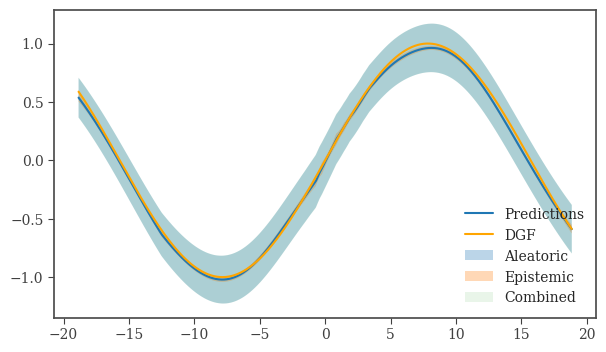

In [7]:
fig, ax = plt.subplots(figsize=(7, 4))

ax.plot(x_numpy, y_pred, label="Predictions")
ax.plot(x_numpy, np.sin(0.2 * x_numpy), label="DGF", color="orange")
ax.fill_between(x_numpy.ravel(), y_pred - aleatoric_std, y_pred + aleatoric_std, label="Aleatoric", alpha=0.3)
ax.fill_between(x_numpy.ravel(), y_pred - epistemic_std, y_pred + epistemic_std, label="Epistemic", alpha=0.3)
ax.fill_between(x_numpy.ravel(), y_pred - total_std, y_pred + total_std, label="Combined", alpha=0.1)

ax.legend()

plt.show()

## Bayesian Neural Network with Variational Inference

A Bayesian Neural Network treats parameters as distributions instead of weights. The implementation used here stores the mean and variance of a normal distribution for each weight. Since full computation of the posterior is impossible, the implementation furthermore uses variational inference, where the posterior is approximated using a simpler distribution. Furthermore, since this relies on differentiating with respect to the parameters we sample from, the reparametrization trick is used.

In [8]:
bnn_vi = BNNVI(x.shape[1])
optimizer = Adam(bnn_vi.parameters(), lr=0.01)

for epoch in range(1000):
    optimizer.zero_grad()

    y_mean, y_log_var = bnn_vi(x)

    loss = negative_elbo(y_mean, y_log_var, y, bnn_vi.kl_divergence())
    loss.backward()

    optimizer.step()
    if epoch % 100 == 0:
        print(f"E{epoch}: Loss {loss.item():.4f}")

E0: Loss 3.3572
E100: Loss 2.9001
E200: Loss 2.5823
E300: Loss 2.5511
E400: Loss 2.4333
E500: Loss 2.5644
E600: Loss 2.4704
E700: Loss 2.6780
E800: Loss 2.4460
E900: Loss 2.3981


In the inference step, several weights are sample using Monte Carlo sampling. From these samples, the mean, epistemic and aleatoric variances are predicted.

In [11]:
x_long = torch.from_numpy(x_numpy).to(torch.float32)

y_pred, var_pred, total_var_pred = bnn_vi.predict(x_long)

y_pred = y_pred.detach().numpy().ravel()
var_pred = var_pred.detach().numpy().ravel()

total_var = total_var_pred.detach().numpy().ravel()

epistemic_var = total_var - var_pred
epistemic_std = epistemic_var ** 0.5

aleatoric_std = var_pred ** 0.5

total_std = total_var ** 0.5

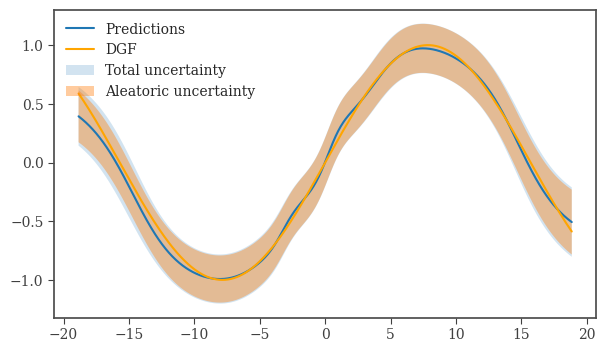

In [12]:
fig, ax = plt.subplots(figsize=(7, 4))

ax.plot(x_numpy, y_pred, label="Predictions")
ax.plot(x_numpy, np.sin(0.2 * x_numpy), label="DGF", color="orange")
ax.fill_between(x_numpy.ravel(), y_pred - total_std, y_pred + total_std, alpha=0.2, label="Total uncertainty", )
ax.fill_between(x_numpy.ravel(), y_pred - aleatoric_std, y_pred + aleatoric_std, alpha=0.4, label="Aleatoric uncertainty", )

ax.legend()

plt.show()